In [14]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import torch
import os
from sklearn.model_selection import train_test_split
from scipy.io import loadmat
import seaborn as sns
sns.set_style("whitegrid")
from model import *
from torch.utils.data import DataLoader, Dataset

torch.set_default_dtype(torch.float64)

In [22]:
data = loadmat('dataset.mat')
X = data['X']
Y = data['X_dot']
t = data['T']
#XX = np.append(X,t,axis=1)
#X.shape, Y.shape, t.shape

# Add noise
noise_level = 0.1
X_noise = X + np.random.normal(0.0, noise_level, X.shape)
XX = np.append(X_noise,t,axis=1)

N = 50
sigma = 4
reg_param = 0.001

W = np.random.randn(3,N) / sigma
b = np.random.uniform(0, 2*np.pi, size=(N,))

# compute random features matrix and coefficients
A = np.cos(XX @ W + b) * np.sqrt(2/N)
c1 = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y[:,0])
c2 = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y[:,1])

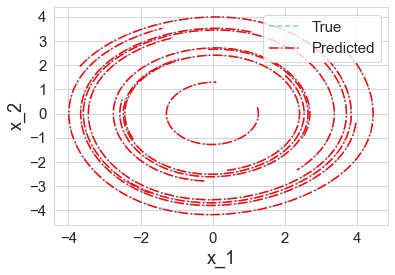

In [23]:
def g(x,t):
    x1, x2 = x
    A = np.cos(W[0] * x1 + W[1] * x2 + W[2] * t + b)
    return [np.sum(A * c1.reshape(-1) * np.sqrt(2/N)), np.sum(A * c2.reshape(-1) * np.sqrt(2/N))]

def fun(x, t, mu):
    x1, x2 = x
    return [x2, mu * (1-x1**2) * x2 - x1]


mu = 0.02

# time stamps
deltat = 0.01
t = np.arange(0.14, 5.15, deltat)
# 10 initial conditions
m_test =10
x_0 = np.random.uniform(-4,4,size=(m_test,2))

for i in range(m_test):
    
    # solve
    sol = odeint(fun, x_0[i], t, args=(mu,))
    sol_app = odeint(g, x_0[i], t)

    # transpose the solution, each row is a trajectory
    data = sol.T
    data1 = sol_app.T
    
    plt.plot(data[0], data[1], '--', c='skyblue')
    plt.plot(data1[0], data1[1], '-.', c='red')

plt.legend(['True', 'Predicted'], fontsize=15 )
plt.xticks(size=15)
plt.yticks(size=15)
plt.xlabel(r'x_1', size=18)
plt.ylabel(r'x_2', size=18)
plt.savefig('Eg3_sol_noise1.pdf', bbox_inches = 'tight')

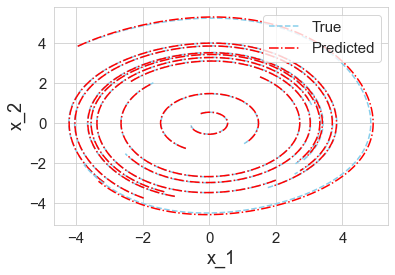

In [39]:
## 5%
# Add noise
data = loadmat('dataset.mat')
X = data['X']
Y = data['X_dot']
t = data['T']
noise_level = np.sqrt(0.05)
X_noise = X + np.random.normal(0.0, noise_level, X.shape)
XX = np.append(X_noise,t,axis=1)

N = 50
sigma = 4
reg_param = 0.001

W = np.random.randn(3,N) / sigma
b = np.random.uniform(0, 2*np.pi, size=(N,))

# compute random features matrix and coefficients
A = np.cos(XX @ W + b) * np.sqrt(2/N)
c1 = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y[:,0])
c2 = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y[:,1])

mu = 0.02

# time stamps
deltat = 0.01
t = np.arange(0.14, 5.15, deltat)
# 10 initial conditions
m_test = 10
x_0 = np.random.uniform(-4,4,size=(m_test,2))

for i in range(m_test):
    
    # solve
    sol = odeint(fun, x_0[i], t, args=(mu,))
    sol_app = odeint(g, x_0[i], t)

    # transpose the solution, each row is a trajectory
    data = sol.T
    data1 = sol_app.T
    
    plt.plot(data[0], data[1], '--', c='skyblue')
    plt.plot(data1[0], data1[1], '-.', c='red')

plt.legend(['True', 'Predicted'], fontsize=15 )
plt.xticks(size=15)
plt.yticks(size=15)
plt.xlabel(r'x_1', size=18)
plt.ylabel(r'x_2', size=18)
plt.savefig('Eg3_sol_noise2.pdf', bbox_inches = 'tight')